# 02 · Результати та аналіз — оптимізація для Raspberry Pi

**Що це.** Підсумковий ноутбук проєкту «спуск затвора на рись» (Raspberry Pi CM5).
Він читає **вже заморожені** результати (Phase D — драбина оптимізації, Phase F — заміри
на реальному Pi) і будує таблиці та графіки, які вимагає DESIGN §17. Нічого не
перераховує з нуля: числа приходять з `results/analysis/canonical_results.json` та
сирих JSON/`.npz`, а самі фігури зберігаються у `results/analysis/figures/` — щоб звіт
і слайди показували рівно те саме.

**Головний результат.** На реальному Pi CM5 фінальна модель **M2 (INT8 QAT)** працює
**у 2.27× швидше** за FP32-базу (20.4 → 46.3 FPS), при **у 3.5× меншому** розмірі
(8.95 → 2.54 MB) і без втрати точності (навіть краще на in-distribution). Рішення
Pi↔gx10 побітово збігаються.

**Дисципліна тесту (DESIGN §5.4).** Тестові спліти відкриті лише один раз — під час
заморозки (F4). Тут ми читаємо ті самі заморожені передбачення, нової інференції на
тесті немає.


In [1]:
# --- середовище та шляхи -----------------------------------------------
%matplotlib inline
import json, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display


def find_proj(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "DESIGN.md").exists() and (p / "results").exists():
            return p
    raise RuntimeError("не знайдено корінь final_project")


PROJ = find_proj(Path.cwd().resolve())
sys.path.insert(0, str(PROJ / "src"))
R = PROJ / "results"
FIG = R / "analysis" / "figures"; FIG.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 130, "font.size": 11,
                     "axes.grid": True, "grid.alpha": 0.3, "figure.autolayout": True})
C = {"M0": "#555555", "M1": "#9ecae1", "M2": "#1f77b4", "M3": "#c7e9c0", "M4": "#2ca02c"}


def load(rel):
    p = R / rel
    return json.loads(p.read_text()) if p.exists() else None


def savefig(fig, name):
    out = FIG / f"{name}.png"
    fig.savefig(out, bbox_inches="tight")
    print("saved", out.relative_to(PROJ))


CANON = load("analysis/canonical_results.json")
assert CANON, "run scripts/build_canonical_results.py first"
print("final model:", CANON["final_model"], "| baseline:", CANON["baseline"])
print("headline:", CANON["headline"])


final model: M2 (int8_qat) | baseline: M0 (fp32_baseline)
headline: M0 FP32 49.06 ms / 20.4 FPS -> M2 INT8 QAT 21.61 ms / 46.3 FPS = 2.27x on the real Raspberry Pi CM5, 3.5x smaller (8.95 -> 2.54 MB), Pi<->gx10 parity bit-identical, accuracy-equivalent (M2 better in-distribution).


## 1 · Драбина оптимізації (валідація) — таблиця та точність-vs-розмір

DESIGN §17.5/§17.8. П'ять кандидатів від FP32-бази до pruned+QAT. «Score» — це
пред-реєстрований відбірковий бал (середнє bobcat-F2 @0.5). Усі — `recall_floor_infeasible`
(поріг 90% recall недосяжний у 5%-бюджеті хибних спрацювань — це виміряний факт §6.3,
а не збій). Розмір і MACs — те, що безпосередньо впливає на швидкість і пам'ять на Pi.


,kind,score,cis F2,trans F2,MB,MACs (M),params,threshold,status
model,,,,,,,,,
M0,fp32_baseline,0.3663,0.6272,0.1054,8.95,293,2244368,0.5381,recall_floor_infeasible
M1,int8_ptq,0.3527,0.6015,0.1039,2.62,293,2244368,0.4964,recall_floor_infeasible
M2,int8_qat,0.3832,0.6499,0.1166,2.54,293,2244368,0.6504,recall_floor_infeasible
M3,pruned_fp32,0.3583,0.5879,0.1287,7.04,206,1761720,0.8000,recall_floor_infeasible
M4,pruned_qat,0.3730,0.6529,0.0930,2.01,206,1761720,0.5439,recall_floor_infeasible


saved results/analysis/figures/ladder_accuracy_vs_size.png


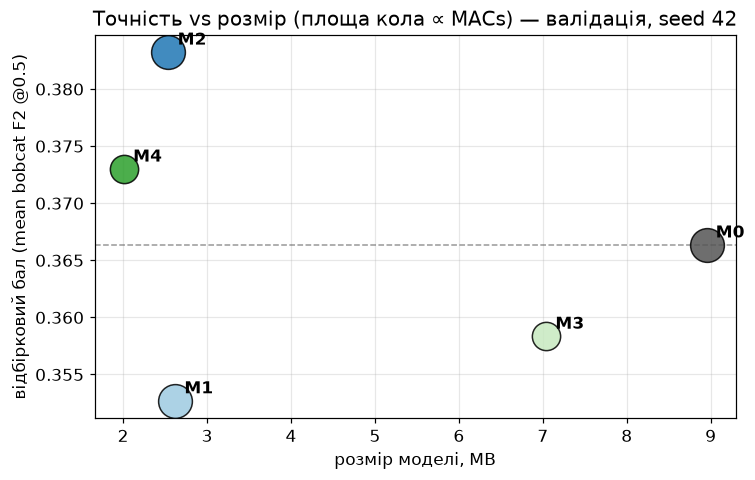

In [2]:
ladder = CANON["optimization_ladder_validation"]
rows = []
for m in ["M0", "M1", "M2", "M3", "M4"]:
    d = ladder[m]
    rows.append({"model": m, "kind": d["kind"], "score": round(d["selection_score_seed42"], 4),
                 "cis F2": round(d["cis_f2_at_0p5"], 4), "trans F2": round(d["trans_f2_at_0p5"], 4),
                 "MB": d["mb"], "MACs (M)": round(d["macs"]/1e6), "params": d["params"],
                 "threshold": round(d["threshold"], 4), "status": d["status"]})
ladder_df = pd.DataFrame(rows).set_index("model")
display(ladder_df)

# accuracy vs size, marker size ~ MACs
fig, ax = plt.subplots(figsize=(7, 4.5))
for m in ["M0", "M1", "M2", "M3", "M4"]:
    d = ladder[m]
    ax.scatter(d["mb"], d["selection_score_seed42"], s=d["macs"]/6e5,
               color=C[m], edgecolor="black", zorder=3, alpha=0.85)
    ax.annotate(m, (d["mb"], d["selection_score_seed42"]),
                textcoords="offset points", xytext=(6, 5), fontweight="bold")
ax.axhline(ladder["M0"]["selection_score_seed42"], color="#555", ls="--", lw=1, alpha=0.6)
ax.set_xlabel("розмір моделі, MB"); ax.set_ylabel("відбірковий бал (mean bobcat F2 @0.5)")
ax.set_title("Точність vs розмір (площа кола ∝ MACs) — валідація, seed 42")
savefig(fig, "ladder_accuracy_vs_size"); plt.show()


## 2 · Замір на реальному Pi CM5 — латентність, FPS, пам'ять (DESIGN §17.9)

Замороженою конфігурацією (`threads=1`, повний decode, `ORT_ENABLE_ALL`, arena on,
fused, 256×192) на **реальному Raspberry Pi CM5** (Cortex-A76 @ 2.4 GHz, governor
`performance`, без тротлінгу), 3 окремих процеси × ≥1000 ітерацій. **Це і є результат,
що рахується** (DESIGN §12.4) — не діагностика на gx10.


,precision,MB,decode ms,preproc ms,infer ms,e2e p50 ms,±ms,FPS,RSS MB
model,,,,,,,,,
M0,FP32,8.95,6.05,1.06,41.35,49.063,1.138,20.38,96.5
M2,INT8 QAT,2.54,6.12,1.04,14.29,21.605,0.356,46.29,89.1
M4,INT8 pruned+QAT,2.01,6.08,1.12,10.60,17.740,0.206,56.37,82.2


speedups vs M0: {'M0_to_M2': 2.271, 'M0_to_M4': 2.766}


saved results/analysis/figures/pi_latency_fps.png


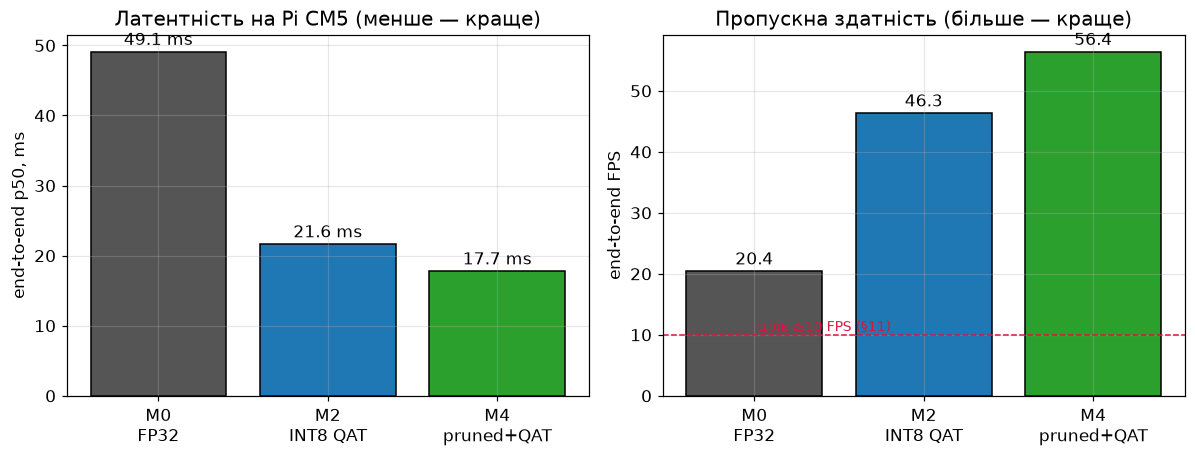

In [3]:
pi = CANON["pi_latency_frozen"]
# per-stage p50 for the three carried models, from the frozen benchmark rep1
rows = []
for m in ["M0", "M2", "M4"]:
    d = pi[m]
    st = d["stages_ms_p50_rep1"]
    rows.append({"model": m, "precision": {"M0": "FP32", "M2": "INT8 QAT", "M4": "INT8 pruned+QAT"}[m],
                 "MB": ladder[m]["mb"], "decode ms": round(st["decode"], 2),
                 "preproc ms": round(st["preprocess"], 2), "infer ms": round(st["inference"], 2),
                 "e2e p50 ms": d["e2e_ms_p50_mean"], "±ms": d["e2e_ms_p50_spread"],
                 "FPS": d["fps_mean"], "RSS MB": d["peak_rss_mb"]})
pi_df = pd.DataFrame(rows).set_index("model")
display(pi_df)
print("speedups vs M0:", CANON["pi_speedups"])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
ms = [pi[m]["e2e_ms_p50_mean"] for m in ["M0", "M2", "M4"]]
fps = [pi[m]["fps_mean"] for m in ["M0", "M2", "M4"]]
cols = [C[m] for m in ["M0", "M2", "M4"]]
b1 = a1.bar(["M0\nFP32", "M2\nINT8 QAT", "M4\npruned+QAT"], ms, color=cols, edgecolor="black")
a1.bar_label(b1, fmt="%.1f ms", padding=2); a1.set_ylabel("end-to-end p50, ms")
a1.set_title("Латентність на Pi CM5 (менше — краще)")
b2 = a2.bar(["M0\nFP32", "M2\nINT8 QAT", "M4\npruned+QAT"], fps, color=cols, edgecolor="black")
a2.bar_label(b2, fmt="%.1f", padding=2); a2.set_ylabel("end-to-end FPS")
a2.set_title("Пропускна здатність (більше — краще)")
a2.axhline(10, color="crimson", ls="--", lw=1); a2.text(0.02, 10.6, "ціль ≥10 FPS (§11)", color="crimson", fontsize=9)
savefig(fig, "pi_latency_fps"); plt.show()


## 3 · Де витрачається час — і як зсувається вузьке місце (DESIGN §17.9/§11)

Decode (~6 мс) і препроцес (~1 мс) однакові для всіх моделей. Змінюється лише інференс:
для FP32 він 85% пайплайна, а INT8+pruning ріже його у 4×, тож у M4 вузьке місце
переходить із моделі на JPEG-decode. Це пояснює, чому квантизація дає такий виграш і де
шукати наступний.


saved results/analysis/figures/pi_stage_breakdown.png


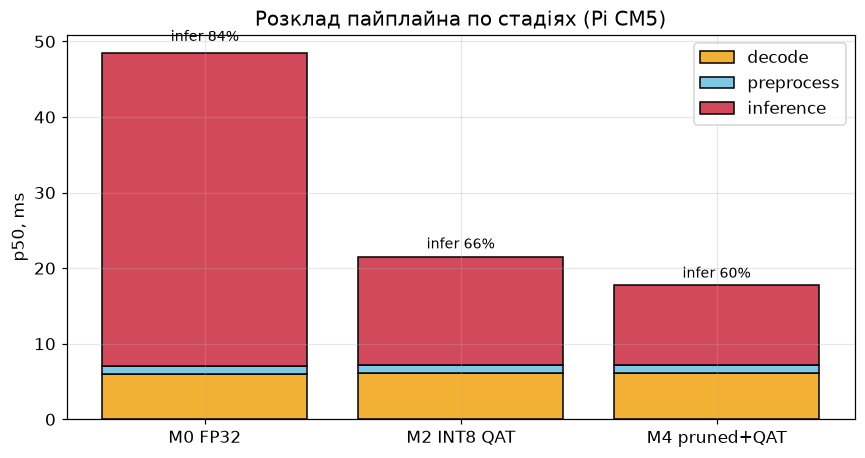

In [4]:
stages = ["decode", "preprocess", "inference"]
fig, ax = plt.subplots(figsize=(8, 4.3))
bottom = np.zeros(3); xs = ["M0 FP32", "M2 INT8 QAT", "M4 pruned+QAT"]
scols = {"decode": "#f2b134", "preprocess": "#7ec8e3", "inference": "#d1495b"}
for s in stages:
    vals = [pi[m]["stages_ms_p50_rep1"][s] for m in ["M0", "M2", "M4"]]
    ax.bar(xs, vals, bottom=bottom, label=s, color=scols[s], edgecolor="black")
    bottom += np.array(vals)
for i, m in enumerate(["M0", "M2", "M4"]):
    inf = pi[m]["stages_ms_p50_rep1"]["inference"]; tot = pi[m]["e2e_ms_p50_mean"]
    ax.text(i, tot + 1, f"infer {inf/tot*100:.0f}%", ha="center", fontsize=9)
ax.set_ylabel("p50, ms"); ax.set_title("Розклад пайплайна по стадіях (Pi CM5)")
ax.legend()
savefig(fig, "pi_stage_breakdown"); plt.show()


## 4 · Потоки та knob-матриця (DESIGN §17.11) — target-специфічна знахідка

На 4-ядерному A76 **threads=3 оптимальний для всіх трьох моделей** — протилежно до gx10
(20 ядер), де threads=4 регресував. Reduced decode (half/quarter) дає лише ~1.05–1.08×,
але **відхилений** ще на E6, бо втрачає реальні детекції рисі. Тому фінал лишається на
повному decode і threads=1 (щоб паритет з замороженим еталоном був чистий), а threads —
задокументована необов'язкова оптимізація.


saved results/analysis/figures/pi_thread_scaling.png


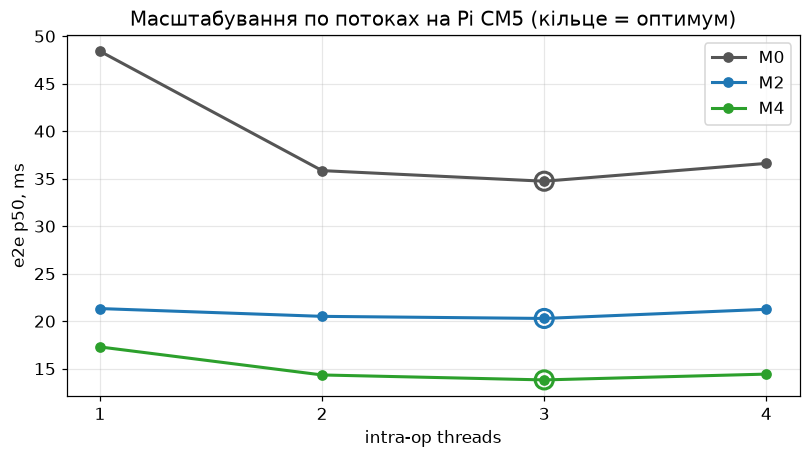

,e2e p50 ms,speedup vs base
knob,,
arena_off,47.85,1.008
baseline,48.23,1.000
decode_half,45.99,1.049
decode_quarter,44.55,1.082
graph_extended,49.24,0.979
preprocess_reference,50.16,0.961
threads2,35.82,1.346
threads3,32.54,1.482
threads4,34.90,1.382


In [5]:
f2 = load("f2/f2_summary.json")
tm = f2["thread_matrix"]
fig, ax = plt.subplots(figsize=(7.5, 4.3))
xs = [1, 2, 3, 4]
for m in ["M0", "M2", "M4"]:
    ys = [tm[m][f"t{t}"]["e2e_ms_p50"] for t in xs]
    ax.plot(xs, ys, "-o", color=C[m], label=f"{m}", lw=2)
    best = tm[m]["best"]; bt = int(best[1]); by = tm[m][best]["e2e_ms_p50"]
    ax.scatter([bt], [by], s=140, facecolor="none", edgecolor=C[m], lw=2, zorder=5)
ax.set_xticks(xs); ax.set_xlabel("intra-op threads"); ax.set_ylabel("e2e p50, ms")
ax.set_title("Масштабування по потоках на Pi CM5 (кільце = оптимум)"); ax.legend()
savefig(fig, "pi_thread_scaling"); plt.show()

knob = f2["m0_knob_matrix"]
kdf = pd.DataFrame([{"knob": k, "e2e p50 ms": round(v["e2e_ms_p50"], 2),
                     "speedup vs base": v.get("speedup_vs_baseline")}
                    for k, v in knob.items()]).set_index("knob")
display(kdf)


## 5 · Парето: точність vs латентність на Pi (DESIGN §17.10)

Валідаційний bobcat-score проти виміряної на Pi p95-латентності. M2 і M4 домінують M0 на
обох осях; M2 обрано за пред-реєстрованим правилом §8.4 (M4 не точніший за M2, тож
простіший стек виграє). M1/M3 не носили на Pi (вибули до оренди), тож у них немає
Pi-латентності — показані лише як довідка по валідації.


saved results/analysis/figures/pareto_accuracy_latency.png


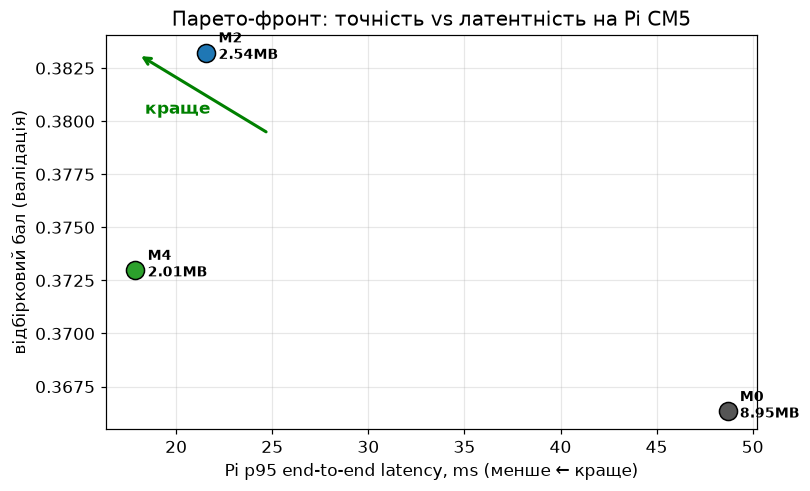

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4.6))
for m in ["M0", "M2", "M4"]:
    x = pi[m]["stages_ms_p50_rep1"]  # ensure key present
    # p95 from the frozen bench rep1
    b = load(f"f4/bench_{m}_rep1.json")
    p95 = b["stages_ms"]["end_to_end"]["p95"]
    y = ladder[m]["selection_score_seed42"]
    ax.scatter(p95, y, s=140, color=C[m], edgecolor="black", zorder=3)
    ax.annotate(f"{m}\n{ladder[m]['mb']}MB", (p95, y), textcoords="offset points",
                xytext=(8, -4), fontweight="bold", fontsize=9)
ax.set_xlabel("Pi p95 end-to-end latency, ms (менше ← краще)")
ax.set_ylabel("відбірковий бал (валідація)")
ax.set_title("Парето-фронт: точність vs латентність на Pi CM5")
ax.annotate("", xy=(0.05, 0.95), xytext=(0.25, 0.75), xycoords="axes fraction",
            arrowprops=dict(arrowstyle="->", color="green", lw=2))
ax.text(0.06, 0.80, "краще", color="green", transform=ax.transAxes, fontweight="bold")
savefig(fig, "pareto_accuracy_latency"); plt.show()


## 6 · Криві навчання M0 та фінальної M2 (DESIGN §17.4)

M0 — двофазний fine-tuning MobileNetV2 (seed 42). M2 — QAT-донавчання з чекпойнта M0
(6 епох, lr 5e-5). Показуємо відбірковий бал по епохах і позначаємо обрану епоху.


saved results/analysis/figures/training_curves.png


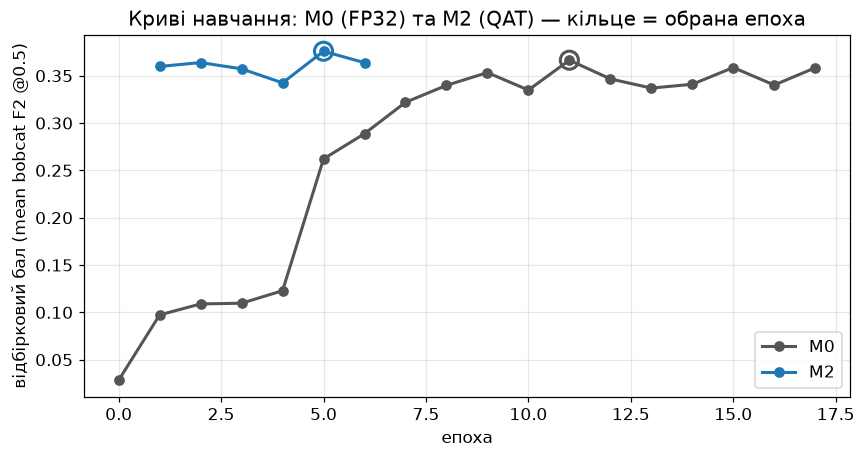

In [7]:
import glob
def load_history(pattern):
    hits = sorted(glob.glob(str(R / pattern)))
    if not hits: return None
    h = json.loads(Path(hits[0]).read_text())
    return h

def epoch_scores(h):
    ep = h.get("epochs") or h.get("history") or []
    xs, ys = [], []
    for i, e in enumerate(ep):
        s = e.get("selection_score")
        if isinstance(s, dict): s = s.get("primary")
        if s is None: s = e.get("val_selection_score") or e.get("score")
        if s is not None: xs.append(e.get("epoch", i + 1)); ys.append(s)
    return xs, ys

h0 = load_history("training/c2/c2_m0_fp32_seed42_20260716T061203Z/history.json")
h2 = load_history("optimize/m2_qat/runs/d2/d2_m2_qat_lr5e-5_*/history.json")
fig, ax = plt.subplots(figsize=(8, 4.3))
for h, m in [(h0, "M0"), (h2, "M2")]:
    if not h: continue
    xs, ys = epoch_scores(h)
    if not xs: continue
    ax.plot(xs, ys, "-o", color=C[m], label=f"{m}", lw=2)
    be = h.get("best_epoch")
    if be is not None:
        bs = h.get("best_selection_score", {})
        bs = bs.get("primary") if isinstance(bs, dict) else h.get("best_score")
        if bs is not None: ax.scatter([be], [bs], s=140, facecolor="none", edgecolor=C[m], lw=2, zorder=5)
ax.set_xlabel("епоха"); ax.set_ylabel("відбірковий бал (mean bobcat F2 @0.5)")
ax.set_title("Криві навчання: M0 (FP32) та M2 (QAT) — кільце = обрана епоха"); ax.legend()
savefig(fig, "training_curves"); plt.show()


## 7 · Метрики цілі з довірчими інтервалами (DESIGN §17.6)

Bootstrap по кластерах-послідовностях (кадри в межах візиту корельовані). Показуємо
frame-F2 та false-fire на cis-val-clean і trans-val для фінальної M2 з CI, а також
невизначеність порога. Джерело — `calibration.json` (10 000 реплік).


обраний поріг: 0.6504 | bootstrap 95% CI порога: [0.4970, 0.9144] (median 0.7049, 1000 реплік по кластерах-послідовностях)


,domain,metric,point,lo95,hi95
0,cis_val_clean,frame_f2,0.6400,0.5413,0.7216
1,cis_val_clean,frame_recall,0.7431,0.6286,0.8524
2,cis_val_clean,false_fire_rate,0.0498,0.0382,0.0624
3,trans_val,frame_f2,0.0976,0.0707,0.1273
4,trans_val,frame_recall,0.0807,0.0582,0.1060
5,trans_val,false_fire_rate,0.0461,0.0287,0.0665


saved results/analysis/figures/metric_confidence_intervals.png


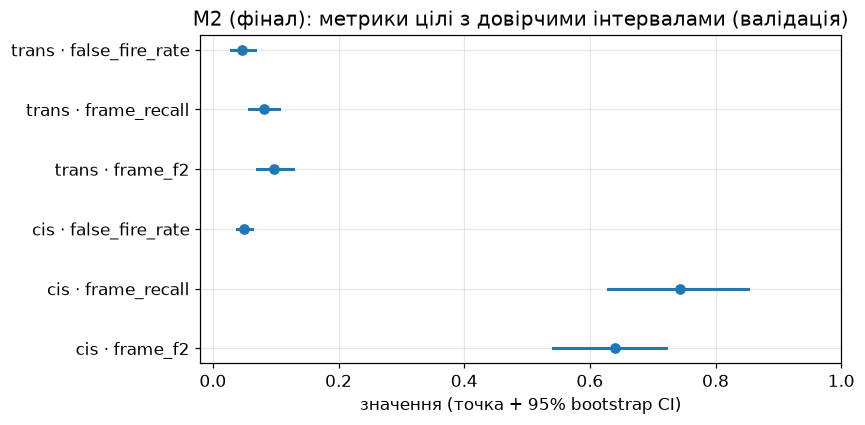

In [8]:
cal = load("optimize/m2_qat/lr5e-5/calibration.json")
tb = cal.get("threshold_bootstrap", {})
mi = cal.get("metric_intervals", {})
thr = cal["selection"]["threshold"]
print(f"обраний поріг: {thr:.4f} | bootstrap 95% CI порога: "
      f"[{tb.get('ci95_low'):.4f}, {tb.get('ci95_high'):.4f}] (median {tb.get('median'):.4f}, "
      f"{tb.get('replicates')} реплік по кластерах-послідовностях)")
rows = []
for dom in ["cis_val_clean", "trans_val"]:
    dd = mi.get(dom, {})
    for metric in ["frame_f2", "frame_recall", "false_fire_rate"]:
        ci = dd.get(metric, {})
        rows.append({"domain": dom, "metric": metric,
                     "point": round(ci.get("point_estimate", float("nan")), 4),
                     "lo95": round(ci.get("ci95_low", float("nan")), 4),
                     "hi95": round(ci.get("ci95_high", float("nan")), 4)})
ci_df = pd.DataFrame(rows)
display(ci_df)

# forest-style plot of the metric CIs for the final model
fig, ax = plt.subplots(figsize=(8, 4))
ypos = range(len(rows))
for i, r in enumerate(rows):
    ax.plot([r["lo95"], r["hi95"]], [i, i], color="#1f77b4", lw=2)
    ax.plot(r["point"], i, "o", color="#1f77b4")
ax.set_yticks(list(ypos), [f"{r['domain'].replace('_val','').replace('_clean','')} · {r['metric']}" for r in rows])
ax.set_xlabel("значення (точка + 95% bootstrap CI)"); ax.set_xlim(-0.02, 1.0)
ax.set_title("M2 (фінал): метрики цілі з довірчими інтервалами (валідація)")
savefig(fig, "metric_confidence_intervals"); plt.show()


## 8 · Матриці плутанини на замороженому тесті (DESIGN §17.7)

Бінарна задача «рись/не-рись» на порозі фіналу, на held-out cis-test та trans-test, для
бази M0 і фінальної M2. Мульти-лейбл кадри лишаються у presence-метриках (ціль може бути
присутня поряд з іншим класом). Числа — із заморожених F4-передбачень.


saved results/analysis/figures/confusion_frozen_test.png


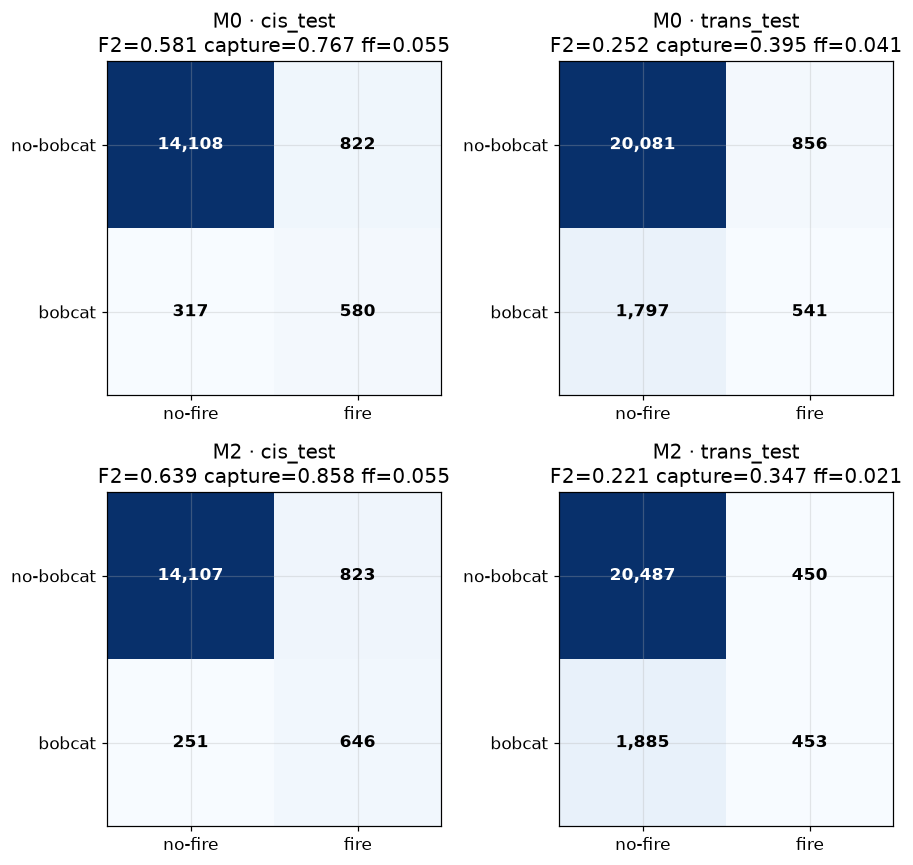

In [9]:
from wildlife_trigger import metrics as WM
from wildlife_trigger.validate.p4_dataset_parity import load_cpp_jsonl

def confusion(model, split):
    pred = R / f"f4/gx10_test_{model}_{split}.jsonl"
    if not pred.exists():  # raw preds are gitignored; fall back to frozen metrics
        return None
    _, rows, _ = load_cpp_jsonl(pred)
    man = {}
    with (PROJ / "data/manifests" / f"{split}.jsonl").open() as fh:
        for line in fh:
            if line.strip():
                r = json.loads(line); man[r["image_id"]] = r["labels"]
    tp = fp = fn = tn = 0
    for r in rows:
        if r.get("skipped"): continue
        present = "bobcat" in man[r["image_id"]]; fire = bool(r["shutter_trigger"])
        tp += present and fire; fp += (not present) and fire
        fn += present and (not fire); tn += (not present) and (not fire)
    return np.array([[tn, fp], [fn, tp]])

ft = CANON["frozen_full_test"]
fig, axes = plt.subplots(2, 2, figsize=(8.5, 8))
for i, m in enumerate(["M0", "M2"]):
    for j, split in enumerate(["cis_test", "trans_test"]):
        ax = axes[i][j]
        cm = confusion(m, split)
        if cm is None:
            d = ft[m]["per_domain"][split]
            # reconstruct from frozen metrics if raw preds absent
            pos = d["positive_frames"]; tot = d["frames_scored"]; neg = tot - pos
            tp = round(d["frame_recall"] * pos); fn = pos - tp
            fp = round(d["false_fire_rate"] * neg); tn = neg - fp
            cm = np.array([[tn, fp], [fn, tp]])
        ax.imshow(cm, cmap="Blues")
        for (r, c), v in np.ndenumerate(cm):
            ax.text(c, r, f"{v:,}", ha="center", va="center",
                    color="white" if v > cm.max()/2 else "black", fontweight="bold")
        ax.set_xticks([0, 1], ["no-fire", "fire"]); ax.set_yticks([0, 1], ["no-bobcat", "bobcat"])
        d = ft[m]["per_domain"][split]
        ax.set_title(f"{m} · {split}\nF2={d['frame_f2']:.3f} capture={d['event_capture_rate']:.3f} ff={d['false_fire_rate']:.3f}")
savefig(fig, "confusion_frozen_test"); plt.show()


## 9 · Варіативність по seed (17/42/73)

Пред-реєстровані підтверджувальні seed (не гейтять фриз). QAT (M2) не лише вищий за
базу, а й **стабільніший** по seed (менший розкид), і навіть на найгіршому seed
залишається вищим за M4 — це підкріплює вибір M2.


saved results/analysis/figures/seed_variability.png


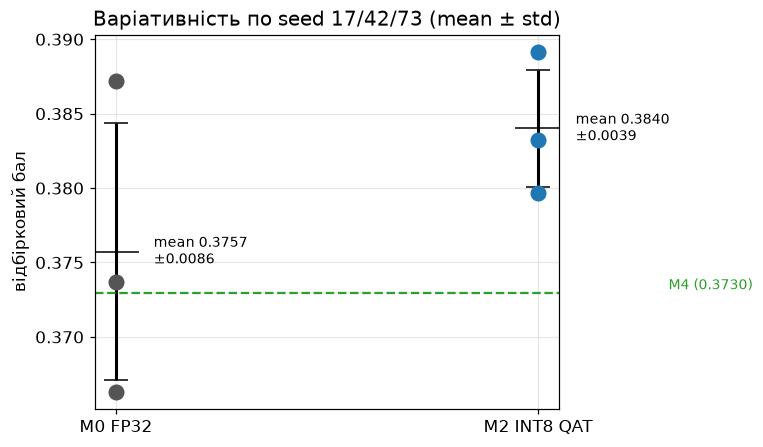

In [10]:
sv = CANON["seed_variability"]
fig, ax = plt.subplots(figsize=(7, 4.2))
for i, (m, key) in enumerate([("M0", "M0_fp32"), ("M2", "M2_int8_qat")]):
    b = sv[key]; vals = [b["per_seed"][f"seed{s}"] for s in (17, 42, 73)]
    ax.scatter([i]*3, vals, s=90, color=C[m], zorder=3)
    ax.errorbar(i, b["mean"], yerr=b["std"], fmt="_", color="black", capsize=8, lw=2, ms=30)
    ax.text(i+0.08, b["mean"], f" mean {b['mean']:.4f}\n ±{b['std']:.4f}", va="center", fontsize=9)
ax.axhline(ladder["M4"]["selection_score_seed42"], color=C["M4"], ls="--", lw=1.5)
ax.text(1.3, ladder["M4"]["selection_score_seed42"], " M4 (0.3730)", color=C["M4"], va="bottom", fontsize=9)
ax.set_xticks([0, 1], ["M0 FP32", "M2 INT8 QAT"]); ax.set_ylabel("відбірковий бал")
ax.set_title("Варіативність по seed 17/42/73 (mean ± std)")
savefig(fig, "seed_variability"); plt.show()


## 10 · Репрезентативні помилки (DESIGN §17.12) — не ховаємо негатив

Шість кадрів валідації, де фінальна M2 помиляється: пропущені рисі (низький score при
присутній цілі) та хибні спрацювання (високий score без цілі). Беремо з заморожених
валідаційних передбачень; підписуємо score і поріг. Це і є та сама «погана» trans-recall,
про яку чесно сказано в звіті.


saved results/analysis/figures/failure_cases.png


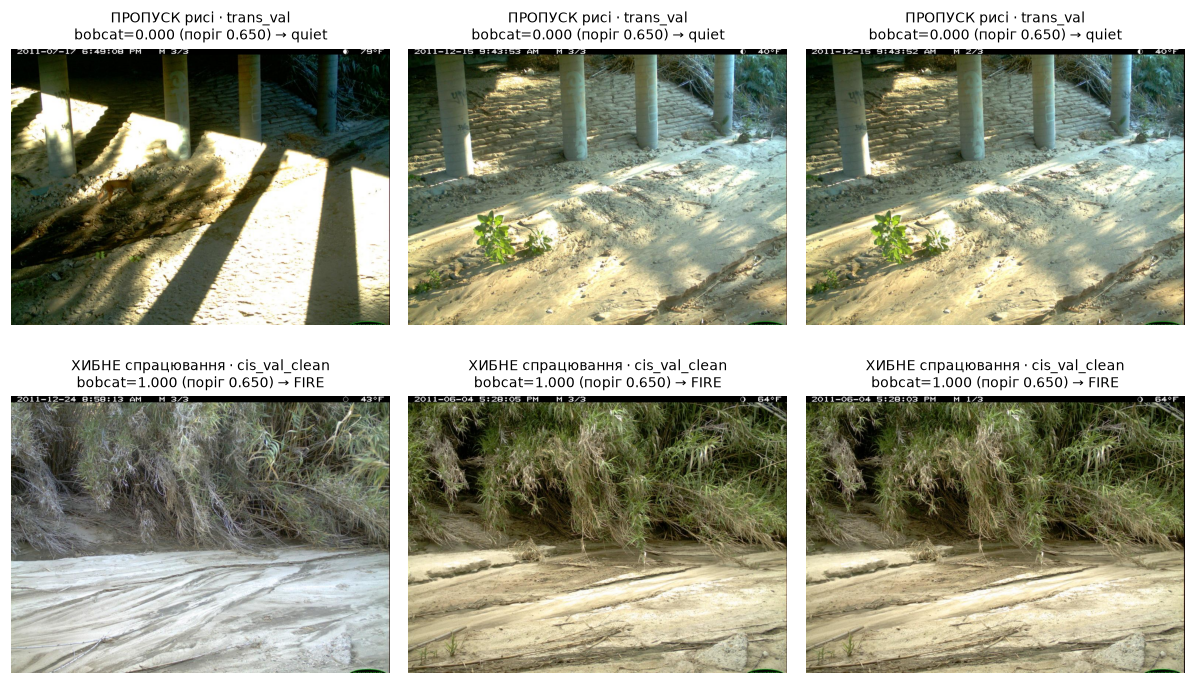

In [11]:
npz = np.load(R / "optimize/m2_qat/lr5e-5/predictions.npz", allow_pickle=False)
cls = [str(c) for c in npz["class_names"]]; bi = cls.index("bobcat")
thr = CANON["optimization_ladder_validation"]["M2"]["threshold"]
IMROOT = PROJ / "data/raw/extracted/eccv_18_all_images_sm"

def pick(split, want_present, n):
    scores = npz[f"{split}/probabilities"][:, bi]
    present = npz[f"{split}/present"][:, bi] > 0
    ids = [str(i) for i in npz[f"{split}/image_ids"]]
    idx = np.where(present == want_present)[0]
    # missed = present & low score; false fire = absent & high score
    order = idx[np.argsort(scores[idx])] if want_present else idx[np.argsort(-scores[idx])]
    out = []
    for k in order:
        p = IMROOT / f"{ids[k]}.jpg"
        if p.exists(): out.append((ids[k], float(scores[k]), split, want_present));
        if len(out) >= n: break
    return out

cases = pick("trans_val", True, 3) + pick("cis_val_clean", False, 3)
fig, axes = plt.subplots(2, 3, figsize=(11, 7)); axes = axes.ravel()
for ax, (iid, sc, split, present) in zip(axes, cases):
    try:
        import matplotlib.image as mpimg
        ax.imshow(mpimg.imread(IMROOT / f"{iid}.jpg"))
    except Exception as e:
        ax.text(0.5, 0.5, "нема кадру", ha="center")
    kind = "ПРОПУСК рисі" if present else "ХИБНЕ спрацювання"
    fired = sc >= thr
    ax.set_title(f"{kind} · {split}\nbobcat={sc:.3f} (поріг {thr:.3f}) → {'FIRE' if fired else 'quiet'}", fontsize=9)
    ax.axis("off")
savefig(fig, "failure_cases"); plt.show()


## 11 · Як ми це робили і що пробували

- **Драбина оптимізації.** M0 FP32 → M1 PTQ (програв — на depthwise MobileNetV2 PTQ
  втрачає точність, лишили як негативний результат) → M2 QAT (найкращий бал) → M3
  structured pruning (округлення ширин до кратних 8, щоб нуль-результат був про
  архітектуру, а не про SIMD) → M4 pruned+QAT (найшвидший/найменший, але не точніший за
  M2). Фінал — **M2** за пред-реєстрованим правилом §8.4 (складніший стек не виграє за
  замовчуванням).
- **C++ на Pi.** Вся інференція — C++ + ONNX Runtime CPU EP; Python лише для тренування і
  конвертації. Паритет Python↔C++ і Pi↔gx10 — побітовий (INT8 акумулює в int32 точно).
- **Що дало виграш.** Квантизація (INT8) — головний важіль: інференс -4×. Потоки на Pi
  (threads=3) — ще ~1.25× (target-специфічно, протилежно gx10). Reduced decode
  виміряли, але відхилили — втрачає рись.
- **Що не спрацювало / межі.** Trans-домен (нові локації): recall лишається низьким для
  всіх моделей — це задокументоване обмеження, а не збій. Поріг 90% recall недосяжний у
  5%-бюджеті (`recall_floor_infeasible`). Немає камери/GPIO/живлення — оренда Pi, saved
  dataset.


In [12]:
# --- фінальна перевірка: канонічна таблиця узгоджена -----------------
assert CANON["pi_vs_gx10_parity"]["verdict"].startswith("PASS"), "паритет Pi↔gx10 має бути PASS"
assert abs(CANON["pi_speedups"]["M0_to_M2"] - 2.27) < 0.05, "очікуємо ~2.27× для M2"
print("OK — усі фігури збережені у", FIG.relative_to(PROJ))
print("headline:", CANON["headline"])


OK — усі фігури збережені у results/analysis/figures
headline: M0 FP32 49.06 ms / 20.4 FPS -> M2 INT8 QAT 21.61 ms / 46.3 FPS = 2.27x on the real Raspberry Pi CM5, 3.5x smaller (8.95 -> 2.54 MB), Pi<->gx10 parity bit-identical, accuracy-equivalent (M2 better in-distribution).
